<a href="https://colab.research.google.com/github/dayquispe/sales-discount-analytics/blob/main/sales_discount_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Contexto de Negócio

Uma empresa de e-commerce busca compreender o comportamento de compra de seus clientes com o objetivo de otimizar suas estratégias de vendas, precificação e campanhas promocionais. A partir da análise dos dados de transações, a empresa pretende identificar padrões relacionados a descontos, categorias de produtos e métodos de pagamento.

# Problema de Negócio

Qual é o impacto dos descontos na receita e no comportamento de compra dos clientes, e como otimizar sua aplicação por categoria para maximizar faturamento?

# Perguntas de Análise
- Como os descontos influenciam a receita total do e-commerce?
- Existe uma faixa de desconto que maximiza a receita?
- Produtos com maiores descontos apresentam maior volume de compras?
- Quais categorias de produtos mais utilizam descontos?
- O impacto dos descontos varia entre diferentes categorias?
- O valor final das compras aumenta ou diminui com maiores descontos?
- O método de pagamento muda conforme o nível de desconto?
- Existe um padrão de compras ao longo do tempo relacionado a promoções?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/dayquispe/sales-discount-analytics/main/ecommerce_dataset.csv"
df = pd.read_csv(url)

In [2]:
df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   object 
 1   Product_ID        3660 non-null   object 
 2   Category          3660 non-null   object 
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   object 
 7   Purchase_Date     3660 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 228.9+ KB


#2. Coleta de Dados
Os dados utilizados neste projeto foram obtidos a partir da plataforma Kaggle, por meio do dataset “E-commerce Dataset”, disponibilizado para fins de análise de dados.

O conjunto de dados é composto por informações fictícias de transações realizadas em um e-commerce, simulando padrões comuns de comportamento de compra. Ele inclui atributos relevantes como categorias de produtos, preços, descontos aplicados, métodos de pagamento e datas de compra.

O arquivo utilizado está no formato CSV e contém 3.660 registros e 8 variáveis, representando diferentes aspectos das transações.

É importante destacar que os dados são sintéticos e não representam transações reais, sendo utilizados exclusivamente para fins educacionais. Ainda assim, permitem simular análises de negócio e extrair insights relevantes sobre o comportamento do consumidor.

## Descrição das Variáveis

### As variáveis presentes no dataset são descritas a seguir:

- `User_ID`: Identificador único de cada usuário
- `Product_ID`: Identificador único de cada produto
- `Category`: Categoria do produto (ex: Electronics, Clothing, Sports)
- `Price (Rs.)`: Preço original do produto antes do desconto
- `Discount (%)`: Percentual de desconto aplicado
- `Final_Price(Rs.)`: Preço final do produto após o desconto
- `Payment_Method`: Método de pagamento utilizado na compra
- `Purchase_Date`: Data em que a compra foi realizada

#3. Limpeza e preparação dos dados

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   object 
 1   Product_ID        3660 non-null   object 
 2   Category          3660 non-null   object 
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   object 
 7   Purchase_Date     3660 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 228.9+ KB


In [5]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Category,0
Price (Rs.),0
Discount (%),0
Final_Price(Rs.),0
Payment_Method,0
Purchase_Date,0


Não temos dados nulos neste dataset

Aqui convertemos a coluna Purchase_Date para formato de Data

In [6]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], dayfirst=True)

Renomeando as colunas

In [7]:
df.columns = [
    'user_id',
    'product_id',
    'category',
    'price',
    'discount',
    'final_price',
    'payment_method',
    'purchase_date'
]

Vamos criar novas colunas

In [8]:
df['day'] = df['purchase_date'].dt.day
df['month'] = df['purchase_date'].dt.month
df['year'] = df['purchase_date'].dt.year

In [9]:
df.describe()

,price,discount,final_price,purchase_date,day,month,year
count,3660.000000,3660.000000,3660.000000,3660,3660.000000,3660.000000,3660.0
mean,254.800675,18.825137,206.906579,2024-06-13 00:46:01.967213056,15.637432,5.912295,2024.0
min,10.090000,0.000000,5.890000,2024-01-01 00:00:00,1.000000,1.000000,2024.0
25%,134.012500,5.000000,104.512500,2024-03-24 00:00:00,8.000000,3.000000,2024.0
50%,253.845000,15.000000,199.185000,2024-06-11 12:00:00,15.000000,6.000000,2024.0
75%,377.595000,25.000000,304.117500,2024-09-03 00:00:00,23.000000,9.000000,2024.0
max,499.960000,50.000000,496.820000,2024-11-21 00:00:00,31.000000,11.000000,2024.0
std,141.682621,14.731338,122.687844,NaN,8.654680,3.096907,0.0


In [10]:
df.isna().sum()

,0
user_id,0
product_id,0
category,0
price,0
discount,0
final_price,0
payment_method,0
purchase_date,0
day,0
month,0


Verificar se temos duplicatas

In [11]:
df.duplicated().sum()

np.int64(0)

Limpeza e Preparação dos Dados

Nesta etapa, foi realizada a preparação dos dados para garantir sua qualidade e adequação às análises propostas.

Inicialmente, verificou-se a existência de valores nulos, não sendo identificadas inconsistências no conjunto de dados.

Em seguida, a variável Purchase_Date foi convertida para o formato de data, permitindo análises temporais.

Também foi realizada a padronização dos nomes das colunas, facilitando a manipulação dos dados.

Por fim, foram criadas novas variáveis derivadas, como mês e ano da compra, além do valor absoluto de desconto, com o objetivo de enriquecer a análise.

In [12]:
df.head()

,user_id,product_id,category,price,discount,final_price,payment_method,purchase_date,day,month,year
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,2024-11-12,12,11,2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,2024-02-09,9,2,2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,2024-09-01,1,9,2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,2024-04-01,1,4,2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,2024-09-27,27,9,2024


In [13]:
df.to_csv('dataset_limpo_br.csv', index=False, decimal=',', sep=';')

In [14]:
df = pd.read_csv('/content/dataset_limpo_br.csv', decimal=',', sep=';')
df.head()

,user_id,product_id,category,price,discount,final_price,payment_method,purchase_date,day,month,year
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,2024-11-12,12,11,2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,2024-02-09,9,2,2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,2024-09-01,1,9,2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,2024-04-01,1,4,2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,2024-09-27,27,9,2024


#4. Análise exploratória

## 1. Análise Univariada
## Análise das variáveis NUMÉRICAS

### análise da variável PRICE (preço original)

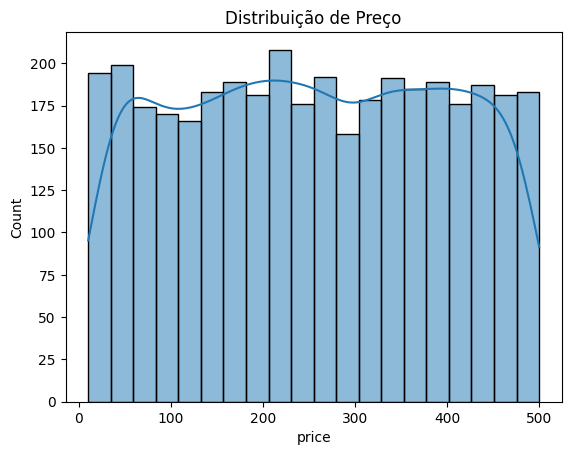

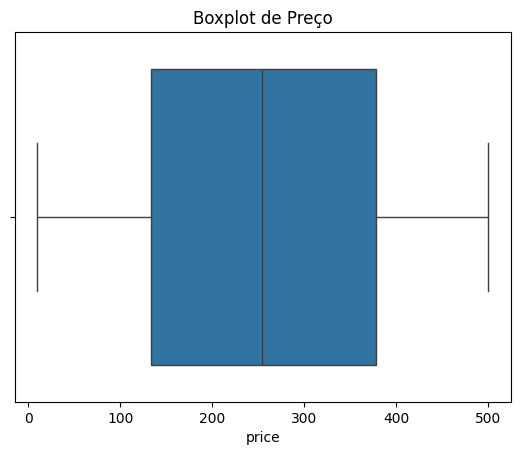

,price
count,3660.000000
mean,254.800675
std,141.682621
min,10.090000
25%,134.012500
50%,253.845000
75%,377.595000
max,499.960000


In [15]:
# Histograma
sns.histplot(df['price'], kde=True, bins=20)
plt.title('Distribuição de Preço')
plt.show()

# Boxplot
sns.boxplot(x=df['price'])
plt.title('Boxplot de Preço')
plt.show()

# Estatísticas
df['price'].describe()

O Histograma mostra que:
- os preços estão bem ditribuídos de 10.09 até 499.96
- Não há concentração forte em apenas um intervalo
- A curva KDE indica uma distribuição relativamente uniforme, sem picos extremos

A empresa vende produtos de vários níveis de preço e que não está focada apenas em preços baratos ou caros.

O boxplot mostra:
- A mediana (253.84) está bem no centro, o que indica uma distribuição equilibrada e boa dispersão dos dados.

A estatística:
- Mostra a média e mediana com valores muito próximas, o que nos diz que temos uma distribuição simétrica
- O desvio padrão com valor de 141.6 mostra alta variabilidade o que indica preços bem variados e grande amplitude de valores

### análise da variável DISCOUNT (desconto)

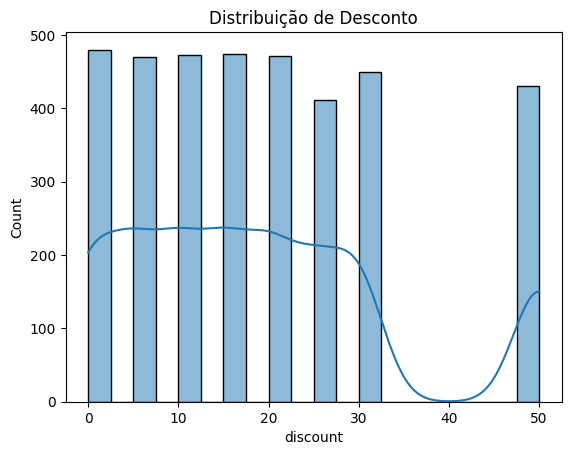

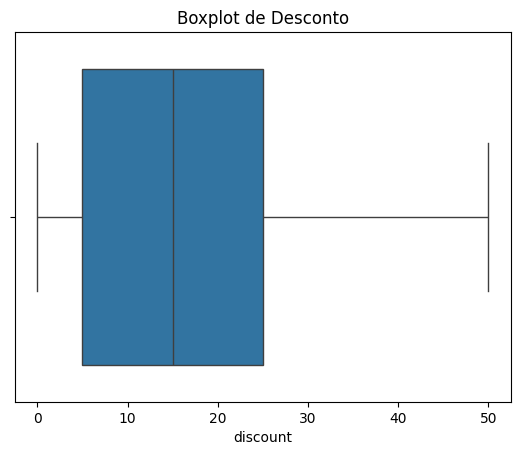

,discount
count,3660.000000
mean,18.825137
std,14.731338
min,0.000000
25%,5.000000
50%,15.000000
75%,25.000000
max,50.000000


In [16]:
sns.histplot(df['discount'], kde=True)
plt.title('Distribuição de Desconto')
plt.show()

sns.boxplot(x=df['discount'])
plt.title('Boxplot de Desconto')
plt.show()

df['discount'].describe()

In [17]:
df.discount.value_counts()


,count
discount,
0,480
15,474
10,473
20,472
5,470
30,449
50,430
25,412


O Histograma mostra:
- Descontos em valores discretos (0%, 5%, 10%, 15%, etc), ou seja temso descontos padronizados
- Maior concentração entre 5% e 25%
- Descontos altos são menos frequentes
A empresa usa descontos moderados, grandes descontos podem ter sido usados para datas especifícas.

O boxplot mostra:
- A mediana com valor de 15%
- 50% dos dados entre 5% e 25%(IQR)
- valor mínimo 0% e máximo 50%
- Nenhum outlier,  descontos bem controlados

A estatística mostra:
- média com valor 18.82% e mediana 15%, a média maior que a mediana, temos uma leve tendência a valores mais altos
- desvio padrão 14.73%, alta variação nos descontos

### análise da variável FINAL_PRICE (preço final)

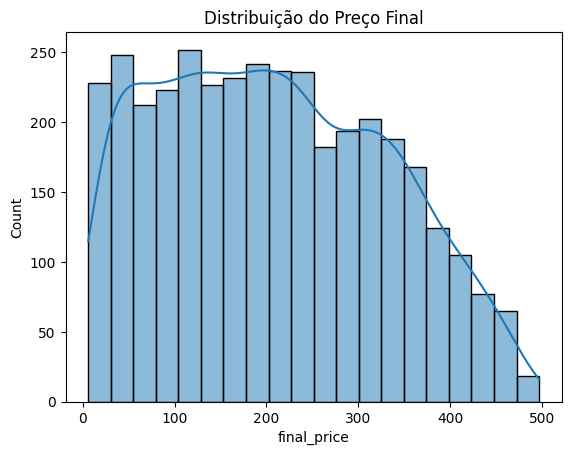

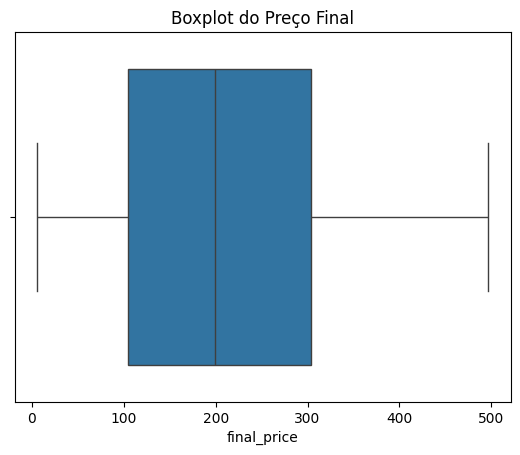

,final_price
count,3660.000000
mean,206.906579
std,122.687844
min,5.890000
25%,104.512500
50%,199.185000
75%,304.117500
max,496.820000


In [18]:
sns.histplot(df['final_price'], kde=True, bins=20)
plt.title('Distribuição do Preço Final')
plt.show()

sns.boxplot(x=df['final_price'])
plt.title('Boxplot do Preço Final')
plt.show()

df['final_price'].describe()

O Histograma mostra:
- a distribuição ligeiramente assimétrica à direita (cauda longa com os valores mais altos)
- há maior concentração de valores entre 50 e 300
- conforme o preço aumenta, a frequência diminui
A maioria das compras ocorre com valores mais baixos e médios, compras muito caras são menos frequentes

O boxplot mostra:
- mediana com valor de 199
- 50% dos valores estão entre 104 e 304
- minimo ~5.8 e máximo ~496
- distribuição bem espalhada

A estatística mostra:
- média com valor ~206.9 e mediana com valor ~199.2
- média um pouco maior, leve assimetria à direita
- desvio padrão com valor de ~122.7, alta variabilidade nos valores pagos.


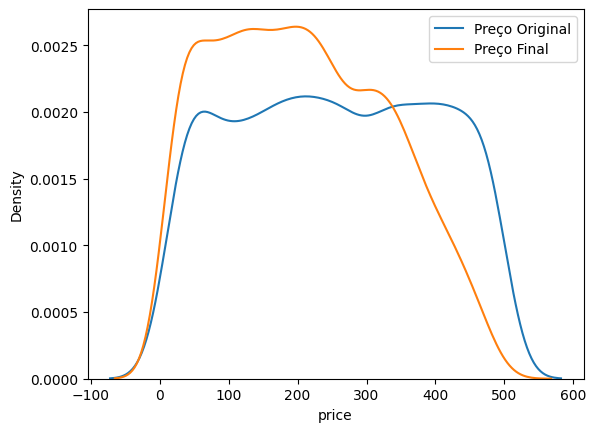

In [19]:
sns.kdeplot(df['price'], label='Preço Original')
sns.kdeplot(df['final_price'], label='Preço Final')
plt.legend()
plt.show()

Comparando com preço médio do valor original e o final:
- preço médio original: 254.800675
- preço médio final: 206.906579

Isso já mostra que os descontos estão impactando o valor final como esperado.

## Análise das variáveis CATEGÓRICAS

### CATEGORY

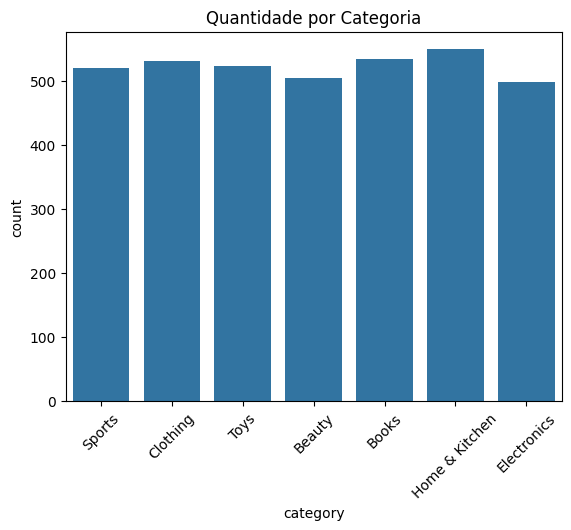

In [20]:
df['category'].value_counts()

sns.countplot(x='category', data=df)
plt.title('Quantidade por Categoria')
plt.xticks(rotation=45)
plt.show()

O gráfico mostra:
- categorias com as quantidades bem próximas
- nenhuma categoria domina fortemente o dataset
- todas as categorias ficam próximas de 500 registros

A categoria com maior volume é o de Home e Kitchen, e com menor volume é o de Eletronics, mas a diferença é bem pequena

### PAYMENT_METHOD

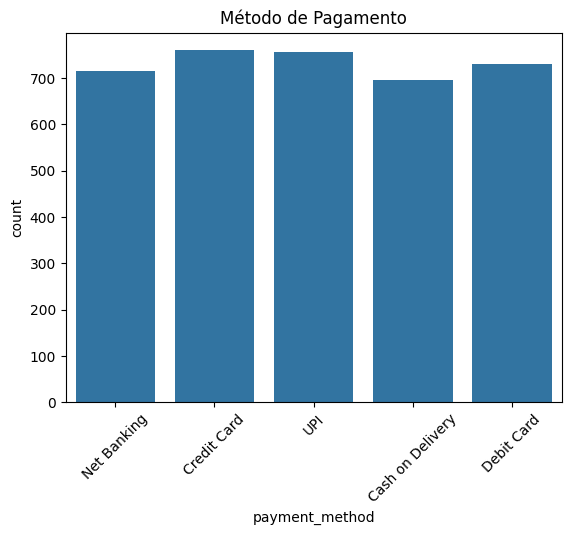

In [21]:
df['payment_method'].value_counts()

sns.countplot(x='payment_method', data=df)
plt.title('Método de Pagamento')
plt.xticks(rotation=45)
plt.show()

O gráfico mostra:
- que todos os metodos de pagamentos tem a quantidade muito semelhante
- não temos um método dominante
- as transaçõs para cada tipo de paga,ento estão próximos de 700 registros
- mas temos o que tem os regostrod de números maiores são o Credit Card e UPI, e com o número de registro menor é o Cash on Delivery


O compartamento de pagamento é bem distribuido, isso nos mostra que a empresa oferece múltiplas formas de pagamento

## Análise TEMPORAL

### MONTH

In [22]:
df['month'].value_counts().sort_index()

,count
month,
1,340
2,308
3,355
4,362
5,333
6,323
7,346
8,344
9,342


Quantidade de compras por mês

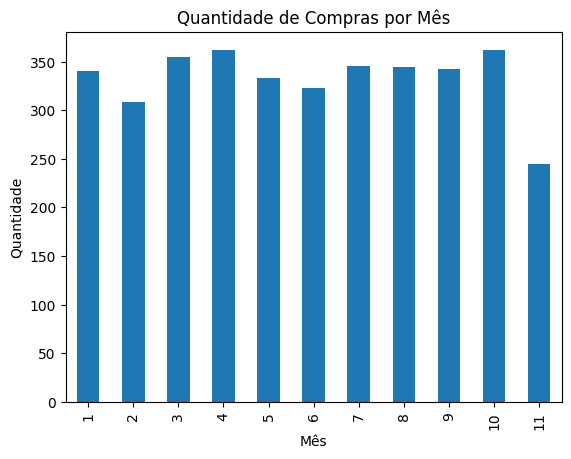

In [23]:
df.groupby('month').size().plot(kind='bar')
plt.title('Quantidade de Compras por Mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.show()

O gráfico mostra:
- que as compras estão relativamente bem distribuidas ao longo do ano
- não temos uma variação forte entre os meses
- mas temos messes com mias vendas que são os meses 3, 4 e 10
- temos o mês 11 com menor quantidade de vendas

O comportamento de compra é estável ao longo do ano, só o mês 11 que o valor é menor:
- isso pode indicar menor atividade ou falta de promoção

### Quantidade de compras por nível de desconto

<Axes: xlabel='discount', ylabel='count'>

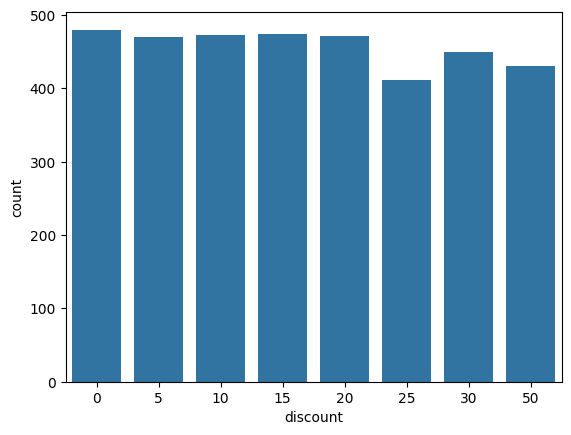

In [24]:
sns.countplot(x='discount', data=df)

O gráfico acima mostra o volume de compras por desconto

## 2. Análise Bivariada

## DESCONTO × PREÇO FINAL

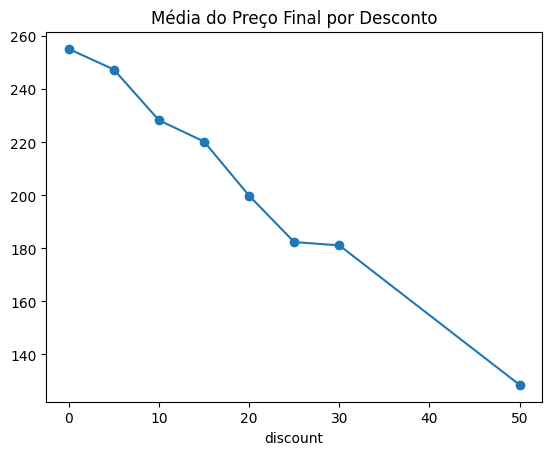

In [25]:
df.groupby('discount')['final_price'].mean().plot(kind='line', marker='o')
plt.title('Média do Preço Final por Desconto')
plt.show()

O gráfico mostra a média do preço do final por desconto, quanto o  cliente paga para cada nível de desconto
- À medida que o desconto aumenta, o preço final médio diminiu

### Mostra o preço final com os descontos aplicados

In [26]:
df.groupby('discount')['final_price'].sum()

,final_price
discount,
0,122503.80
5,116296.25
10,107994.24
15,104419.15
20,94335.76
25,75137.57
30,81332.59
50,55258.72


## CATEGORIA × DESCONTO

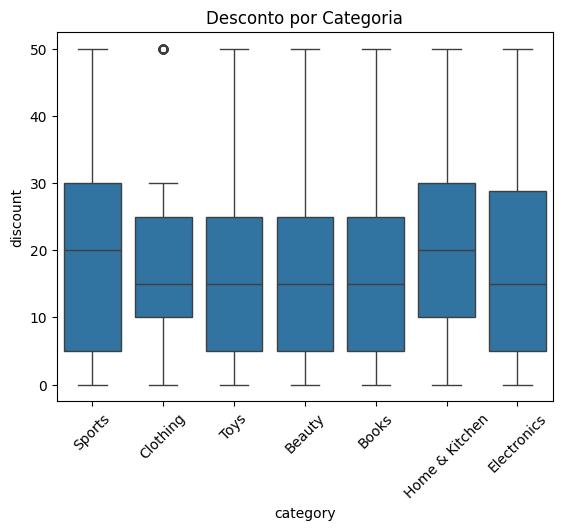

In [27]:
sns.boxplot(x='category', y='discount', data=df)
plt.xticks(rotation=45)
plt.title('Desconto por Categoria')
plt.show()

O gráfico mostra: a distribuição de desconto em cada categoria de produtos
- Todas as categorias têm descontos variando de 0% ate 50%, indicando que a empresa aplica descontos em todos as categorias
- A maioria das categorias têm a mediana próxima de 15% a 20%, ou seja o desconto "padrão" é parecido entre categorias
- Algumas categorias tem maior dispersão como, sport, Home & Kitchen, Eletronics, indicando maior variação de descontos, podendendo ter até algumas promoções mais agressivas
- Temos algumas categorias estáveis como, Clothings, Toys, Beauty, books, onde as caixas são mais concentradas ou seja menos variações nos descontos, isso pode ser estrategias mais consistentes
- Podemos ver um outlier em Clothing, indicando uma promoção pontual mais agressiva

## CATEGORIA × RECEITA

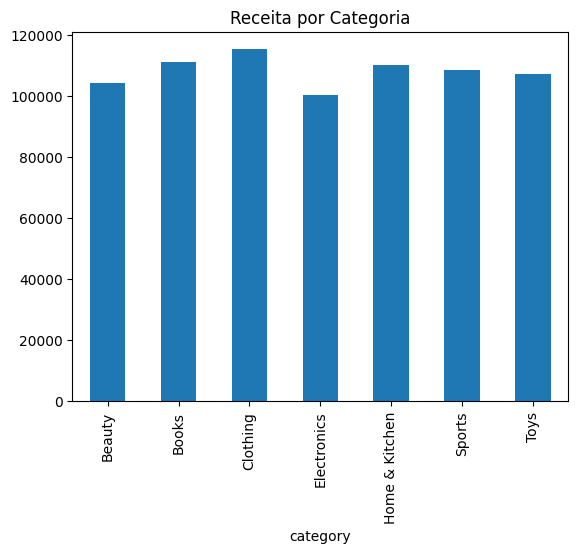

In [28]:
df.groupby('category')['final_price'].sum().plot(kind='bar')
plt.title('Receita por Categoria')
plt.show()

O gráfico mostra quanto cada categoria gera de receita total

- A distribuição geral de todas as categorias têm receitas relativamente próximas, entre valores proximos de 100.000 e 115.000, isso mostra que não temos uma categoria que domine totalmente a receita
- As categorias com maior receita são Xlothings, Books e Home & Kitchen, que contribuem mais para o faturamento total
- As categroias com menor receita são, Eletronics e Beauty, mas a diferença não muito grande

Métodos de Pagamento no E-commerce

No dataset, estão presentes os seguintes métodos:

**Net Banking**

Refere-se ao pagamento realizado diretamente pelo sistema bancário online do cliente, permitindo transferência direta de valores. É considerado seguro, porém menos ágil em comparação a métodos digitais mais modernos.

**Credit Card (Cartão de Crédito)**

Permite que o cliente realize a compra sem possuir o valor total no momento, pagando posteriormente. É amplamente utilizado devido à praticidade e possibilidade de parcelamento.

**UPI (Unified Payments Interface)**

Sistema de pagamento digital instantâneo que permite transferências rápidas entre contas bancárias por meio de aplicativos. Destaca-se pela rapidez e baixo custo.

**Cash on Delivery (Pagamento na Entrega)**

O pagamento é realizado no momento da entrega do produto. Esse método pode aumentar a confiança do consumidor, mas envolve riscos logísticos para a empresa.

**Debit Card (Cartão de Débito)**

O valor é debitado diretamente da conta bancária no momento da compra. É simples e amplamente utilizado, mas depende da disponibilidade imediata de saldo.

## PAGAMENTO × DESCONTO

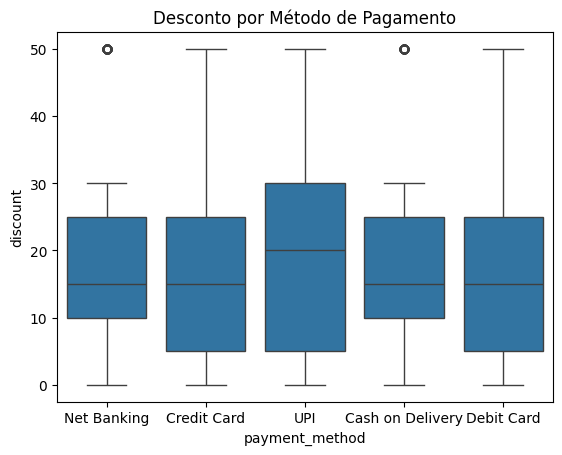

In [29]:
sns.boxplot(x='payment_method', y='discount', data=df)
plt.title('Desconto por Método de Pagamento')
plt.show()

O gráfico mostra se os descontos mudam dependendo do método de pagamento
- A distribuição geral de todos os metodos de pagamento tem descontos entre 0% e 50%, ou seja todos recebem promoções
- A maioria dos métodos têm a mediana próximo de 15%, mas a UPI tem a mediana um pouco maior, isso pode indicar que há um encentivo maior nesse método
- Os métodos com maior dispersão são UPI, Credit Card, Debit Card, isso pode indicar que há mais diversidade de desconto nesses métodos
- Os métodos de pagamento maso estáveis são o Net Banking e Cash on Delivery porque tem menor variação de descontos
- Temos alguns outiliers altos, indicando promoções pontuais mais agressivas

## DESCONTO × RECEITA

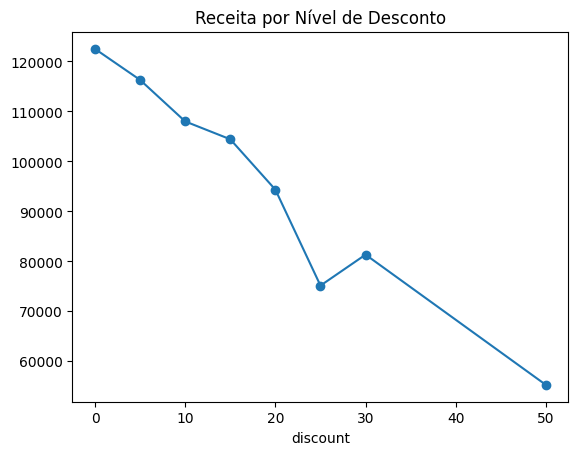

In [30]:
df.groupby('discount')['final_price'].sum().plot(kind='line', marker='o')
plt.title('Receita por Nível de Desconto')
plt.show()

O gráfico mostra quanto dinheiro a empresa ganha em cada nível de desconto
- A tendência é que quando mais o desconto aumenta, a receita diminui
- o aumento do desconto não aumentou a receita e também não compensou com mais vendas, o que temos é que o faturamento foi reduzido

## RECEITA ao longo do tempo

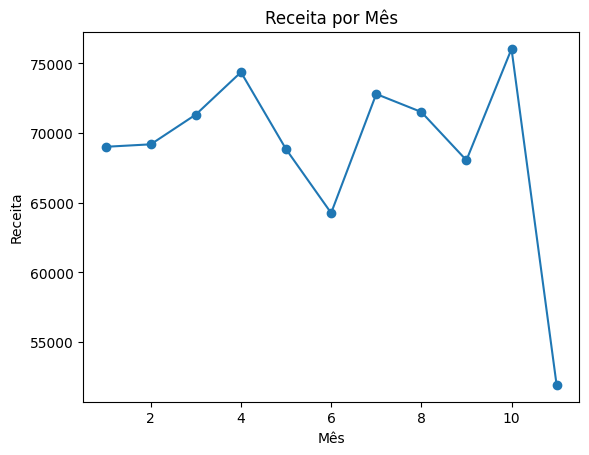

In [31]:
df.groupby('month')['final_price'].sum().plot(kind='line', marker='o')
plt.title('Receita por Mês')
plt.xlabel('Mês')
plt.ylabel('Receita')
plt.show()

O gráfico mostra como a receita varia ao logo dos meses
- a receita se mantém entre 68.000 e 75.000 na maior parte dos meses, isso indica um comportamento relativamente estável
- os meses com maior receita são,  10 (Setembro), 4(Abril), 7(Julho)
- Oe meses com menor receitas são 6(Junho) e 11(Novembro), indicando menor demanda ou falta de promoções

O gráfico mostra pequenas oscilações entre os meses, sem tendência clar de crescimento ou queda contínua

### Verificando se o mês 11 está com todos os dias completo

In [32]:
df.groupby(['month', 'day']).size().unstack(fill_value=0)

day,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
month,,,,,,,,,,,,,,,,,,,,,
1,7,17,9,10,12,8,14,9,16,9,...,11,5,12,4,11,13,13,15,13,14
2,10,6,11,10,13,6,9,9,12,10,...,10,10,11,14,8,14,13,14,0,0
3,13,9,8,11,13,7,10,11,14,20,...,8,12,10,9,8,8,17,19,12,13
4,9,11,9,14,15,9,13,13,11,10,...,12,11,11,14,14,12,18,9,9,0
5,8,11,10,7,8,8,10,16,6,12,...,15,12,16,10,10,7,9,9,15,8
6,19,13,10,19,11,8,12,8,11,8,...,10,9,8,10,9,6,11,9,7,0
7,11,6,11,5,7,5,15,10,11,8,...,11,13,14,13,10,9,12,15,8,10
8,3,11,8,11,9,17,13,14,11,7,...,8,12,15,15,8,10,6,11,12,15
9,12,10,13,10,9,7,12,9,17,14,...,15,18,13,8,9,14,7,14,11,0


In [33]:
df.groupby('month')['day'].nunique()

,day
month,
1,31
2,29
3,31
4,30
5,31
6,30
7,31
8,31
9,30


O mês 11 mostra que não têm todos os dias registrados, já os outros meses tem seu dias completos, mas para 11 são apenas 21 dias, assim a receita desse mês ser a menor não reflete queda de vendas, mas sim a falta de registros dos dias qua faltam

## MÉDIA DE DESCONTO ao longo do tempo

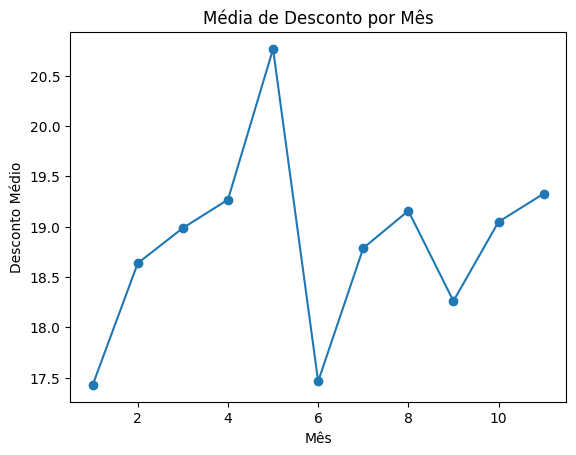

In [34]:
df.groupby('month')['discount'].mean().plot(kind='line', marker='o')
plt.title('Média de Desconto por Mês')
plt.xlabel('Mês')
plt.ylabel('Desconto Médio')
plt.show()

O gráfico mostra como o disconto médio vária ao longo dos meses
- O desconto médio vária entre ~17.5 e ~20.5, ou seja variação pequena e controlada
- O mês com maior desconto é 5 (Maio), o que indica um período com maiores promoções
- O mês com menor desconto é 6 (Junho)
- O menor desconto no mes 6 , explica o porque do gráfico,  sobre receita total no mês 6 ser um dos menores, isso é por conta do menor desconto

## Análise por categoria ao longo do tempo

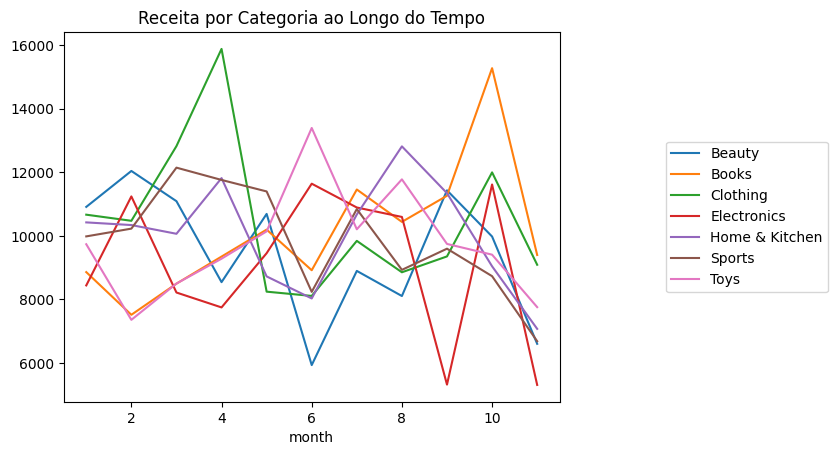

In [35]:
df.groupby(['month', 'category'])['final_price'].sum().unstack().plot().legend(loc='center left', bbox_to_anchor=(1.2, 0.5))
plt.title('Receita por Categoria ao Longo do Tempo')

plt.show()

O gráfico mostra como a receita de cada categoria varia ao longo dos meses
- Todas as categorias apresentam oscilações ao longo do tempo, sem uma tendência contínua de crescimento ou queda
- Vemos momentos de alto desempenho por categoria, como Clothings, Books e Toys
- Vemos também quedas de categorias como Eletronics e Beauty
- No Final vemos que todas as categorias despencam, isso por que não temos para o mês 11 todos os dias resgistrados, somente dias de 1 à 21
- Cada categoria tem seu próprio comportamento

A empresa pode ter estrátegias diferentes por categoria, promoções podem ocorrer em momentos distintos, o desempenho não é uniforme.

## Impacto do Desconto na Receita por Categoria

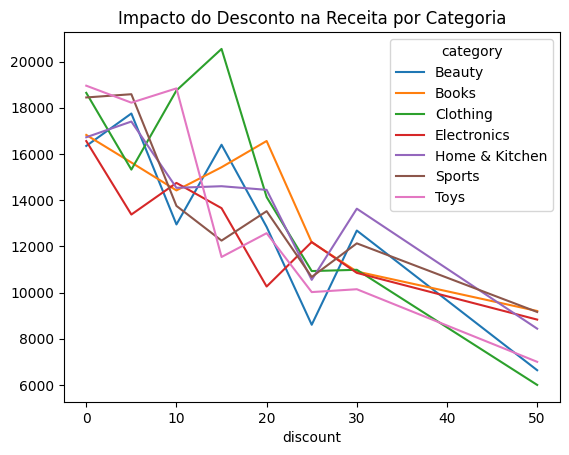

In [36]:
df.groupby(['discount', 'category'])['final_price'].sum().unstack().plot()
plt.title('Impacto do Desconto na Receita por Categoria')
plt.show()

- O gráfico mostra claramente que a receita diminui quando aumentoamos o desconto
- Algumas categorias começam com uma receita mais alta
- Outras tem quedas mais suavez
- Em alguns pontos como 10% e 20% de desconto vemos pequenas oscilações, mas nenhuma sustenta crescimento com desconto alto
- Em altos descontos como 30% e 40% são pontos críticos, pois temos quedas significativas

## Quantidade por método em cada desconto

<Axes: xlabel='discount'>

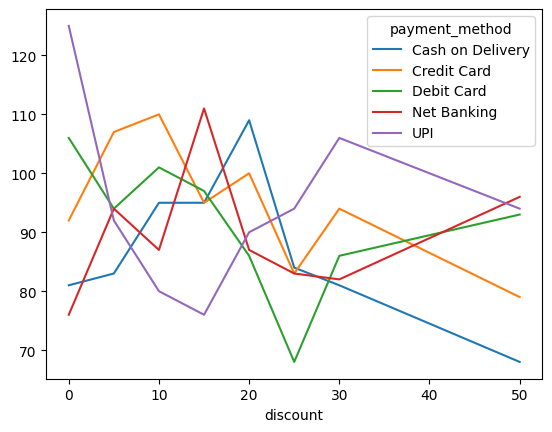

In [37]:
df.groupby(['discount', 'payment_method']).size().unstack().plot()

# 5. Interpretação dos resultados

## Perguntas de Análise

### 1 - Como os descontos influenciam a receita total do e-commerce?
Influenciam de forma negativa, podemos observar na análise de receita por nível de desconto que o faturamento total tende a diminuir com valores de descontos maiores e que os maiores valores de receita ocorrem nos níveis mais baixos desconto, como 0% a 10%.

Dessa forma, conclui-se que os descontos impactam negativamente a receita quando aplicados em níveis elevados, sendo mais vantajoso manter em níveis moderados de desconto.





###2 - Existe uma faixa de desconto que maximiza a receita?
Sim, a análise de receita por nível de  desconto indica que os maiores valores de faturamento estão concentrados nos níves mais baixos de desconto, especialmente entre 0% e 10%.

Quando o nível de desconto aumenta, a receita tende a diminuir, não havendo evidências de que descontos elevados maximizem a receita.

Dessa forma, podemos concluir que faixas de descontos que maximizam a receita está associada a níveis baixos de desconto, enquanto descontos mais altos apresentam impacto negativo de desempenho financeiro.


### 3 - Produtos com maiores descontos apresentam maior volume de compras?
Não, a análise da quantidade de compras por nível de desconto indica que o volume de transações se mantém relativamente estável entre os diferntes níveis de desconto.

Quando comparamos o número de compras em níveis elevados de descontos como 25% ou 50%, podemos ver que são inferiores comparados a outros descontos que são menores.

Dessa forma, conclui-se que produtos com maiores descontos não apresentam, de forma consistente, maior volume de compras.


### 4 - Quais categorias de produtos mais utilizam descontos?
A análise de distribuição de descotos por categoria indica que todas as categorias utilizam descontos em níveis variados, como valores chegando a 50%.

Mas as categorias como Sports e Home & Kitchen se destacam por apresentarem medianas de descontos mais elevados e maior concentração de valores altos, indicando uso mais frequente desses valores mais agressivos.

As outras categorias, como Clothing, Toys, Beauty, Books e Electronics, apresentam níveis de descontos mais moderados, com distrubuição relativamente uniforme

De forma geral, embora existam pequenas diferenças a estratégia de descontos é relativamente consistente entre as categorias, com algumas se destacando pelo uso mais intensivo.




### 5 - O impacto dos descontos varia entre diferentes categorias?

Análisando o gráfico de nível de desconto e receita por categoria, podemos ver que os impactos do descontos nas diferentes categorias não é uniforme.

Mesmo que todas as categorias apresentem quedas na receita quando aumentanso o desconto, a intensidade é diferente para os tipos de categoria. Para categorias como Clothins, observamos que sim é bem sensivel com descontos. Já outras como Home & Kitchen e Books, apresentam receita estável com descontos menores.

E claro com descontos acima de 30%, todas as categorias presnetam queda na significativa na receita.

De forma geral vemos que o impacto dos descontos varia entre as categorias, sugerindo a necessidade de estratégias promocionais diferenciadas para cada tipo de produto.



### 6 - O valor final das compras aumenta ou diminui com maiores descontos?

Obeservando o gráfico de desconto por preço final médio, nos mostra que a medida que o desconto cresce, temos uma queda no preço final.

Temos uma tendência decrescente no valor médio pago pelos clientes conforme o nível de desconto se torna mais elevado, o que é consistente com a lógica de aplicação de descontos sobre o preço original.

Dessa forma, conclui-se que maiores descontos resultam na redução do valor final das compras.


### 7 - O método de pagamento muda conforme o nível de desconto?

Sim muda, para o método de pagamento UPI (pagamento digital instantâneo) podemos observar mudanças da quantiade de pagamento bem radical, onde é bem usado quando não se tem desconto nas categorias, e quando aplicado descotos como 10% , o método de pagamanto UPIé menos usado. Daí podemos ver o aumento do uso de outras formas de pagamento como Net Banking, Credit Card, Cash on Delivery, Debit Card.

Dessa forma podemos concluir que sim o método de pagamento muda conform o nível de desconto.


### 8 - Existe um padrão de compras ao longo do tempo relacionado a promoções?

Não existe um padrão de compras ao longo do tempo. O que podemos ver é que a quantidade de vendas para cada categoria ao longo do tempo é bem variado.